# Giai đoạn 4 — Thuật toán Di truyền (GA) sinh dữ liệu tăng cường

## Bài toán

Hai nguồn dữ liệu của đề tài bổ sung cho nhau nhưng **không nguồn nào đầy đủ**:

| | Điểm thi | Ngành | 10 câu Likert | Giới tính | Mục tiêu |
|---|---|---|---|---|---|
| **TTTH** (15.888 hồ sơ) | ✅ THẬT | ✅ THẬT | ❌ **thiếu** | ❌ **thiếu** | ❌ **thiếu** |
| **Khảo sát** (574 phiếu) | ✅ THẬT | ✅ THẬT | ✅ THẬT | ✅ THẬT | ✅ THẬT |

GA sẽ **bổ sung phần còn thiếu cho hồ sơ TTTH**, dựa trên phân phối đã học ở Giai đoạn 3, và
**giữ nguyên điểm thi thật**:

```
Hồ sơ TTTH thật              Phân phối (Giai đoạn 3)          Dòng tổng hợp
┌───────────────────┐        ┌──────────────────────┐        ┌─────────────────────────┐
│ ma_nganh    THẬT  │        │ vector trung bình    │        │ ma_nganh        THẬT    │
│ to_hop_thi  THẬT  │   +    │ ma trận hiệp         │  ───►  │ to_hop_thi      THẬT    │
│ 3 điểm thi  THẬT  │        │ phương sai 10×10     │        │ 3 điểm thi      THẬT    │
│ Likert    THIẾU   │        └──────────────────────┘        │ 10 Likert     GA SINH   │
│ giới tính THIẾU   │                                        │ giới tính     GA SINH   │
│ mục tiêu  THIẾU   │                                        │ mục tiêu      GA SINH   │
└───────────────────┘                                        └─────────────────────────┘
```

## Vì sao phải dùng GA mà không lấy mẫu thẳng từ phân phối chuẩn?

Vì Likert là **số nguyên 1–5 có chặn hai đầu**. Lấy mẫu từ phân phối chuẩn rồi `clip(1,5)` và
`round()` sẽ gây ba loại méo:

1. **Cắt ở biên** làm lệch trung bình (giá trị 5.4 và 6.2 đều thành 5).
2. **Làm tròn** làm sai độ phân tán.
3. Hai bước trên làm **méo cả ma trận tương quan** giữa các câu.

Đây là bài toán **tối ưu tổ hợp có ràng buộc nguyên** — đúng chỗ GA phát huy tác dụng, và là việc
mà lấy mẫu trực tiếp **không giải được**.

## Thiết kế GA: một cá thể = MỘT BỘ DỮ LIỆU

Thứ cần tối ưu là **phân phối của cả tập**, không phải từng dòng riêng lẻ. Vì vậy mỗi "cá thể" trong
quần thể GA là một **ma trận `n × 10` số nguyên** — tức một bộ dữ liệu tổng hợp hoàn chỉnh cho một ngành.

| Khái niệm GA | Trong bài toán này |
|---|---|
| **Cá thể** | Ma trận `n × 10` số nguyên 1–5 (một bộ dữ liệu hoàn chỉnh của 1 ngành) |
| **Quần thể** | 10 bộ dữ liệu ứng viên |
| **Hàm thích nghi** | −(sai lệch trung bình + độ phân tán + tương quan + hình dạng phân phối) |
| **Chọn lọc** | Tournament (k = 3) |
| **Lai ghép** | Uniform theo dòng — bộ con lấy ngẫu nhiên mỗi dòng từ cha hoặc mẹ |
| **Đột biến** | Thay 6% số dòng bằng dòng mới rút từ phân phối đích (xem bên dưới) |
| **Tinh hoa** | Giữ nguyên 2 bộ tốt nhất mỗi thế hệ |

Hàm thích nghi:

$$\text{loss} = w_1\underbrace{\|\bar{P}-\mu\|}_{\text{trung bình}}
+ w_2\underbrace{\|\sigma_P-\sigma\|}_{\text{độ phân tán}}
+ w_3\underbrace{\|\text{corr}(P)-\text{corr}\|_F}_{\text{tương quan}}
+ w_4\underbrace{\text{TV}(P,\text{đích})}_{\text{hình dạng rời rạc}}$$

### Toán tử đột biến: thay dòng mới ("random immigrants")

Đột biến kiểu sửa từng ô ±1 **không phù hợp với bài toán này**. Lý do: cấu trúc tương quan giữa
10 câu nằm ở **quan hệ giữa các ô trong cùng một dòng**. Sửa từng ô một cách độc lập sẽ phá vỡ quan
hệ đó — càng đột biến nhiều thì tương quan càng lệch khỏi đích, đúng thứ mà cả pipeline đang cố bảo toàn.

Toán tử phù hợp hơn là **thay dòng** (kỹ thuật *random immigrants* trong GA): mỗi thế hệ, thay
khoảng 6% số dòng của bộ con bằng **dòng mới rút từ chính phân phối đích**. Vì mỗi dòng mới được
sinh từ phân phối chuẩn nhiều chiều nên nó **mang sẵn cấu trúc tương quan đúng**, giúp quần thể
tiếp tục khám phá mà không phá hỏng phần đã đạt được.

> Hai toán tử được **đo và so sánh trực tiếp** ở phần dưới, không khẳng định suông.

In [1]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

DATA_DIR   = Path("../data/processed")
SPLIT_DIR  = DATA_DIR / "02_split"
DIST_DIR   = DATA_DIR / "03_distribution"
OUTPUT_DIR = DATA_DIR / "04_synthetic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
CAP_MAX, CAP_MIN = 600, 150       # trần / sàn số dòng tổng hợp mỗi ngành
N_CA_THE, N_THE_HE = 10, 40       # quần thể & số thế hệ
TY_LE_DOT_BIEN, N_ELITE = 0.06, 2   # tỷ lệ dòng bị thay mới mỗi thế hệ
W_MEAN, W_STD, W_CORR, W_HIST = 3.0, 2.0, 2.0, 1.0

LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
NHAN = ["Năng động", "Hướng nội", "Sáng tạo", "Tư duy logic", "Tò mò",
        "Thí nghiệm", "Môi trường", "Dinh dưỡng", "Tranh luận", "Thiết kế"]
DIEM_COLS = ["diem_Toan", "diem_Ly", "diem_Hoa", "diem_Anh", "diem_Van",
             "diem_Su", "diem_Sinh", "diem_Dia", "diem_Gdktpl", "diem_Tin"]
MUC_TIEU_MA = {"Đi làm": 1, "Nghiên cứu": 2, "Kinh doanh": 3, "Chưa xác định": 4}

df_ttth = pd.read_csv(DATA_DIR / "TTTH_processed_flatten.csv")
TAX = json.load(open(SPLIT_DIR / "nganh_khoi_mapping.json", encoding="utf-8"))
NGANH_TO_KHOI = {int(k): v for k, v in TAX["nganh_to_khoi"].items()}
MA_TO_TEN     = {int(k): v for k, v in TAX["ma_to_ten"].items()}
TEN_KHOI      = {int(k): v for k, v in TAX["ten_khoi"].items()}
PP      = json.load(open(DIST_DIR / "phan_phoi_theo_nganh.json", encoding="utf-8"))["theo_nganh"]
PP_FOLD = json.load(open(DIST_DIR / "phan_phoi_theo_fold.json", encoding="utf-8"))["theo_fold"]

print(f"Hồ sơ TTTH  : {len(df_ttth):,} dòng, {df_ttth['ma_nganh'].nunique()} ngành")
print(f"Phân phối   : {len(PP)} ngành  |  bộ theo fold: {len(PP_FOLD)}")

Hồ sơ TTTH  : 15,888 dòng, 34 ngành
Phân phối   : 39 ngành  |  bộ theo fold: 15


## 1. Cài đặt thuật toán di truyền

In [2]:
def _thong_ke(P):
    # Trung bình, độ lệch chuẩn, ma trận tương quan và histogram 5 mức của một bộ dữ liệu
    m = P.mean(axis=0)
    s = P.std(axis=0) + 1e-9
    Z = (P - m) / s
    corr = (Z.T @ Z) / len(P)
    hist = np.stack([np.bincount(P[:, d] - 1, minlength=5) for d in range(P.shape[1])]) / len(P)
    return m, s, corr, hist


def tinh_loss(P, dich):
    # Sai lệch giữa bộ dữ liệu P và phân phối đích — càng nhỏ càng khớp
    m, s, corr, hist = _thong_ke(P)
    D = P.shape[1]
    return (W_MEAN * np.linalg.norm(m - dich["mean"]) / np.sqrt(D)
            + W_STD * np.linalg.norm(s - dich["std"]) / np.sqrt(D)
            + W_CORR * np.linalg.norm(corr - dich["corr"]) / D
            + W_HIST * np.abs(hist - dich["hist"]).sum(axis=1).mean() / 2.0)


def lam_dich(mean, cov, rng, n_ref=20000):
    # Mô tả phân phối đích: trung bình / độ lệch chuẩn / tương quan liên tục,
    # cùng histogram 5 mức lấy từ mẫu tham chiếu lớn đã clip và làm tròn
    ref = np.clip(np.rint(np.clip(rng.multivariate_normal(mean, cov, size=n_ref), 1, 5)), 1, 5).astype(int)
    d = np.sqrt(np.diag(cov))
    return {"mean": mean, "std": d, "corr": cov / np.outer(d, d),
            "hist": np.stack([np.bincount(ref[:, k] - 1, minlength=5) for k in range(len(mean))]) / n_ref}


def sinh_likert_ga(n, mean, cov, rng, n_the_he=N_THE_HE, tra_lich_su=False,
                   kieu_dot_bien="dong_moi"):
    # GA: tìm ma trận n×10 số nguyên 1..5 có phân phối khớp (mean, cov) nhất
    mean, cov = np.asarray(mean), np.asarray(cov)
    D = len(mean)
    dich = lam_dich(mean, cov, rng)

    # Khởi tạo: lấy mẫu chuẩn nhiều chiều rồi clip + làm tròn
    quan_the = np.stack([
        np.clip(np.rint(np.clip(rng.multivariate_normal(mean, cov, size=n), 1, 5)), 1, 5).astype(int)
        for _ in range(N_CA_THE)])
    loss = np.array([tinh_loss(P, dich) for P in quan_the])
    lich_su = [loss.min()]

    for _ in range(n_the_he):
        thu_tu = np.argsort(loss)
        moi = [quan_the[i].copy() for i in thu_tu[:N_ELITE]]          # tinh hoa
        while len(moi) < N_CA_THE:
            cha_me = []
            for _ in range(2):                                        # tournament k=3
                uv = rng.choice(N_CA_THE, size=3, replace=False)
                cha_me.append(uv[np.argmin(loss[uv])])
            mask = rng.random(n) < 0.5                                # lai ghép theo dòng
            con = np.where(mask[:, None], quan_the[cha_me[0]], quan_the[cha_me[1]])
            if kieu_dot_bien == "dong_moi":
                # Thay ~6% số dòng bằng dòng mới rút từ phân phối đích
                # → dòng mới mang sẵn cấu trúc tương quan đúng
                k = max(1, int(n * TY_LE_DOT_BIEN))
                vi_tri = rng.choice(n, size=k, replace=False)
                con = con.copy()
                con[vi_tri] = np.clip(np.rint(np.clip(
                    rng.multivariate_normal(mean, cov, size=k), 1, 5)), 1, 5).astype(int)
            else:
                # Đối chứng: sửa từng ô ±1 một cách độc lập
                db = rng.random((n, D)) < TY_LE_DOT_BIEN
                con = np.clip(con + db * rng.choice([-1, 1], size=(n, D)), 1, 5)
            moi.append(con.astype(int))
        quan_the = np.stack(moi)
        loss = np.array([tinh_loss(P, dich) for P in quan_the])
        lich_su.append(loss.min())

    tot = quan_the[np.argmin(loss)]
    return (tot, lich_su, dich) if tra_lich_su else tot

print("✅ Đã cài đặt GA")

✅ Đã cài đặt GA


## 2. Kiểm chứng: GA có thật sự tốt hơn lấy mẫu thẳng không?

Nếu GA không cải thiện được gì so với `round(clip(lấy mẫu chuẩn))` thì nó chỉ là trang trí và nên bỏ.
Ta chạy thử trên ngành có nhiều dữ liệu nhất để so sánh.

In [3]:
rng_demo = np.random.default_rng(SEED)
ma_demo = "7480201"       # Công nghệ thông tin
mean_d = np.array(PP[ma_demo]["likert_mean"])
cov_d  = np.array(PP[ma_demo]["likert_cov"])

P_ga, lich_su, dich = sinh_likert_ga(600, mean_d, cov_d, rng_demo, tra_lich_su=True)
P_thang = np.clip(np.rint(np.clip(
    rng_demo.multivariate_normal(mean_d, cov_d, size=600), 1, 5)), 1, 5).astype(int)

def sai_lech(P):
    m, s, corr, _ = _thong_ke(P)
    iu = np.triu_indices(10, 1)
    return {"Trung bình": np.abs(m - dich["mean"]).mean(),
            "Độ phân tán": np.abs(s - dich["std"]).mean(),
            "Tương quan": np.abs(corr - dich["corr"])[iu].mean(),
            "Loss tổng": tinh_loss(P, dich)}

sl_thang, sl_ga = sai_lech(P_thang), sai_lech(P_ga)
L_1LAN, L_CHON, L_TIEN_HOA = sl_thang["Loss tổng"], lich_su[0], lich_su[-1]

so_sanh = pd.DataFrame({"Lấy mẫu thẳng": sl_thang, "GA": sl_ga})
so_sanh["Cải thiện"] = (1 - so_sanh["GA"] / so_sanh["Lấy mẫu thẳng"]).map(lambda v: f"{v:.1%}")

print(f"BẢNG 4.1 — Sai lệch so với phân phối đích ({PP[ma_demo]['ten_nganh']}, n = 600)\n")
print(so_sanh.round(4).to_string())

print(f"\n\nBẢNG 4.2 — Tách bạch đóng góp của từng thành phần trong GA\n")
print(f"{'Mức':<44}{'Loss':>9}{'Giảm so với mức trên':>24}")
print("─" * 78)
print(f"{'① Lấy mẫu thẳng (1 lần)':<44}{L_1LAN:>9.4f}{'—':>24}")
print(f"{'② Chọn bộ tốt nhất trong ' + str(N_CA_THE) + ' lần khởi tạo':<44}{L_CHON:>9.4f}"
      f"{1 - L_CHON/L_1LAN:>23.1%}")
print(f"{'③ Sau ' + str(N_THE_HE) + ' thế hệ tiến hoá':<44}{L_TIEN_HOA:>9.4f}"
      f"{1 - L_TIEN_HOA/L_CHON:>23.1%}")
print("─" * 78)
print(f"{'TỔNG CẢI THIỆN (① → ③)':<44}{'':>9}{1 - L_TIEN_HOA/L_1LAN:>23.1%}")
# Đối chứng: cùng khởi tạo nhưng đột biến NGẪU NHIÊN (không định hướng)
P_o, ls_o, _ = sinh_likert_ga(600, mean_d, cov_d, np.random.default_rng(SEED),
                              tra_lich_su=True, kieu_dot_bien="o_ngau_nhien")
L_NGAU_NHIEN = ls_o[-1]
_, _, c_o, _ = _thong_ke(P_o)
_, _, c_dm, _ = _thong_ke(P_ga)
iu_ = np.triu_indices(10, 1)
SL_CORR_O  = float(np.abs(c_o - dich["corr"])[iu_].mean())
SL_CORR_DM = float(np.abs(c_dm - dich["corr"])[iu_].mean())
print(f"\n→ Cả hai thành phần đều đóng góp: chọn lọc quần thể ban đầu VÀ tiến hoá qua các thế hệ.")
print(f"\nBẢNG 4.3 — Đối chứng hai toán tử đột biến (cùng khởi tạo, cùng số thế hệ)\n")
print(f"   {'Toán tử':<26}{'Loss cuối':>11}{'Tiến hoá giảm':>15}{'Sai lệch tương quan':>21}")
print("   " + "─" * 71)
print(f"   {'Sửa từng ô ±1':<26}{L_NGAU_NHIEN:>11.4f}{1 - L_NGAU_NHIEN/ls_o[0]:>14.1%}{SL_CORR_O:>21.4f}")
print(f"   {'Thay dòng mới (đang dùng)':<26}{L_TIEN_HOA:>11.4f}{1 - L_TIEN_HOA/L_CHON:>14.1%}{SL_CORR_DM:>21.4f}")
print("   " + "─" * 71)
print(f"   ⇒ Thay dòng mới vừa giảm loss mạnh hơn, vừa giữ tương quan sát đích hơn.")
print(f"     Sửa từng ô phá vỡ quan hệ giữa các câu trong cùng một dòng.")

BẢNG 4.1 — Sai lệch so với phân phối đích (Công nghệ thông tin, n = 600)

             Lấy mẫu thẳng      GA Cải thiện
Trung bình          0.0351  0.0067     80.8%
Độ phân tán         0.0486  0.0187     61.5%
Tương quan          0.0387  0.0247     36.0%
Loss tổng           0.3647  0.1633     55.2%


BẢNG 4.2 — Tách bạch đóng góp của từng thành phần trong GA

Mức                                              Loss    Giảm so với mức trên
──────────────────────────────────────────────────────────────────────────────
① Lấy mẫu thẳng (1 lần)                        0.3647                       —
② Chọn bộ tốt nhất trong 10 lần khởi tạo       0.2827                  22.5%
③ Sau 40 thế hệ tiến hoá                       0.1633                  42.2%
──────────────────────────────────────────────────────────────────────────────
TỔNG CẢI THIỆN (① → ③)                                                 55.2%



→ Cả hai thành phần đều đóng góp: chọn lọc quần thể ban đầu VÀ tiến hoá qua các thế hệ.

BẢNG 4.3 — Đối chứng hai toán tử đột biến (cùng khởi tạo, cùng số thế hệ)

   Toán tử                     Loss cuối  Tiến hoá giảm  Sai lệch tương quan
   ───────────────────────────────────────────────────────────────────────
   Sửa từng ô ±1                  0.2827          0.0%               0.0279
   Thay dòng mới (đang dùng)      0.1633         42.2%               0.0247
   ───────────────────────────────────────────────────────────────────────
   ⇒ Thay dòng mới vừa giảm loss mạnh hơn, vừa giữ tương quan sát đích hơn.
     Sửa từng ô phá vỡ quan hệ giữa các câu trong cùng một dòng.


   💾 Đã lưu hình: hinh_4_1_ga_hoi_tu.png


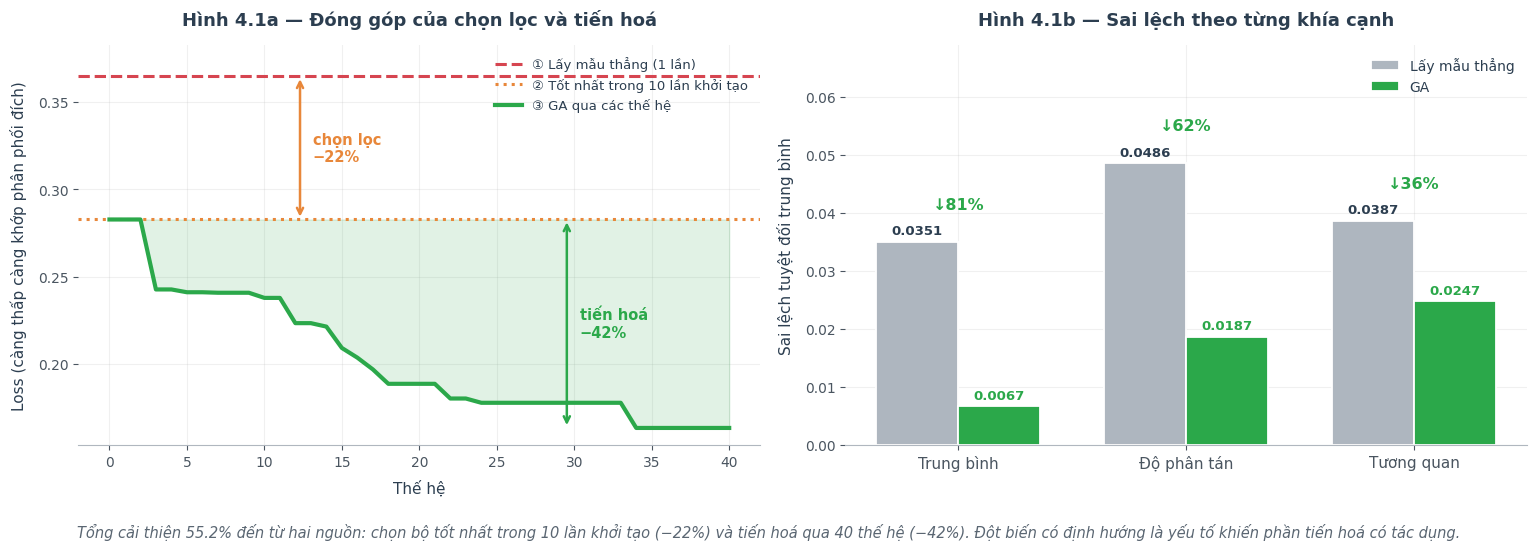

In [4]:
# ═══════════ HÌNH 4.1 — GA hội tụ và cải thiện ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

# (a) Đường hội tụ + hai mốc tham chiếu
ax = axes[0]
ax.axhline(L_1LAN, color=C_THAT, ls="--", lw=2.2, label="① Lấy mẫu thẳng (1 lần)")
ax.axhline(L_CHON, color=C_CAM, ls=":", lw=2.2, label=f"② Tốt nhất trong {N_CA_THE} lần khởi tạo")
ax.plot(lich_su, color=C_GA, lw=3, label="③ GA qua các thế hệ")
ax.fill_between(range(len(lich_su)), lich_su, L_CHON, color=C_GA, alpha=0.14)

ax.annotate("", xy=(len(lich_su) * 0.30, L_CHON), xytext=(len(lich_su) * 0.30, L_1LAN),
            arrowprops={"arrowstyle": "<->", "lw": 1.8, "color": C_CAM})
ax.text(len(lich_su) * 0.32, (L_1LAN + L_CHON) / 2, f"chọn lọc\n−{1 - L_CHON/L_1LAN:.0%}",
        fontsize=10.5, fontweight="bold", color=C_CAM, va="center")
ax.annotate("", xy=(len(lich_su) * 0.72, L_TIEN_HOA), xytext=(len(lich_su) * 0.72, L_CHON),
            arrowprops={"arrowstyle": "<->", "lw": 1.8, "color": C_GA})
ax.text(len(lich_su) * 0.74, (L_CHON + L_TIEN_HOA) / 2, f"tiến hoá\n−{1 - L_TIEN_HOA/L_CHON:.0%}",
        fontsize=10.5, fontweight="bold", color=C_GA, va="center")

ax.set_xlabel("Thế hệ"); ax.set_ylabel("Loss (càng thấp càng khớp phân phối đích)")
ax.set_ylim(L_TIEN_HOA * 0.94, L_1LAN * 1.05)
ax.set_title("Hình 4.1a — Đóng góp của chọn lọc và tiến hoá")
ax.legend(loc="upper right", fontsize=9.5); ax.set_axisbelow(True)

# (b) So sánh 3 loại sai lệch
ax = axes[1]
loai = ["Trung bình", "Độ phân tán", "Tương quan"]
x = np.arange(3); w = 0.36
v_thang = [sl_thang[k] for k in loai]
v_ga    = [sl_ga[k] for k in loai]
ax.bar(x - w/2, v_thang, w, label="Lấy mẫu thẳng", color=C_XAM, edgecolor="white", linewidth=1.3)
ax.bar(x + w/2, v_ga, w, label="GA", color=C_GA, edgecolor="white", linewidth=1.3)
cao = max(max(v_thang), max(v_ga))
for i in range(3):
    ax.text(i - w/2, v_thang[i] + cao * 0.025, f"{v_thang[i]:.4f}", ha="center",
            fontsize=9.5, fontweight="bold")
    ax.text(i + w/2, v_ga[i] + cao * 0.025, f"{v_ga[i]:.4f}", ha="center", fontsize=9.5,
            fontweight="bold", color=C_GA)
    ax.text(i, max(v_thang[i], v_ga[i]) + cao * 0.115,
            f"↓{1 - v_ga[i]/v_thang[i]:.0%}" if v_ga[i] < v_thang[i] else
            f"↑{v_ga[i]/v_thang[i] - 1:.0%}",
            ha="center", fontsize=11.5, fontweight="bold",
            color=C_GA if v_ga[i] < v_thang[i] else C_THAT)
ax.set_xticks(x); ax.set_xticklabels(loai, fontsize=11)
ax.set_ylabel("Sai lệch tuyệt đối trung bình"); ax.set_ylim(0, cao * 1.42)
ax.set_title("Hình 4.1b — Sai lệch theo từng khía cạnh")
ax.legend(); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_4_1_ga_hoi_tu.png",
    f"Tổng cải thiện {1 - L_TIEN_HOA/L_1LAN:.1%} đến từ hai nguồn: chọn bộ tốt nhất trong "
    f"{N_CA_THE} lần khởi tạo (−{1 - L_CHON/L_1LAN:.0%}) và tiến hoá qua {N_THE_HE} thế hệ "
    f"(−{1 - L_TIEN_HOA/L_CHON:.0%}). Đột biến có định hướng là yếu tố khiến phần tiến hoá có tác dụng.")
plt.show()

## 3. Chọn hồ sơ TTTH làm "dòng nền"

Trước khi sinh Likert, cần quyết định mỗi ngành lấy bao nhiêu hồ sơ TTTH:

- Ngành có **> 600** hồ sơ → lấy ngẫu nhiên 600 (giảm mất cân bằng; 600 hồ sơ đã quá đủ để mô tả
  mặt bằng điểm của một ngành).
- Ngành có **< 150** hồ sơ → lấy lặp lên 150. Mỗi bản sao được sinh Likert **khác nhau** nên không
  phải dòng trùng lặp y hệt.
- **5 ngành không có trong TTTH** → mượn hồ sơ điểm từ **kho TTTH của cùng khối ngành**.
  Không lấy từ khảo sát, để tránh dòng tổng hợp vô tình sao chép dòng thật đang nằm trong tập validation.

In [5]:
rng = np.random.default_rng(SEED)
co_ttth = set(df_ttth["ma_nganh"].unique())
ttth_khoi = {k: df_ttth[df_ttth["ma_nganh"].map(NGANH_TO_KHOI) == k] for k in range(7)}

phan = []
for ma, khoi in sorted(NGANH_TO_KHOI.items()):
    if ma in co_ttth:
        kho, nguon = df_ttth[df_ttth["ma_nganh"] == ma], "ttth_that"
        n_lay = int(np.clip(len(kho), CAP_MIN, CAP_MAX))
    else:
        kho, nguon = ttth_khoi[khoi], "ttth_cung_khoi"
        n_lay = CAP_MIN
    idx = rng.choice(len(kho), size=n_lay, replace=n_lay > len(kho))
    sub = kho.iloc[idx].copy().reset_index(drop=True)
    sub["ma_nganh"] = ma
    sub["nguon_diem"] = nguon
    phan.append(sub)

df_nen = pd.concat(phan, ignore_index=True)
df_nen["ma_khoi_nganh"] = df_nen["ma_nganh"].map(NGANH_TO_KHOI)

vc_ttth = df_ttth["ma_nganh"].value_counts()
vc_nen  = df_nen["ma_nganh"].value_counts()

print(f"Dòng nền tổng hợp : {len(df_nen):,} dòng, {df_nen['ma_nganh'].nunique()} ngành\n")
print(f"{'':<26}{'Nhiều nhất':>12}{'Ít nhất':>10}{'Chênh lệch':>13}")
print(f"{'TTTH gốc':<26}{vc_ttth.max():>12,}{vc_ttth.min():>10,}{vc_ttth.max()/vc_ttth.min():>12.0f}×")
print(f"{'Sau khi đặt trần/sàn':<26}{vc_nen.max():>12,}{vc_nen.min():>10,}{vc_nen.max()/vc_nen.min():>12.0f}×")
print(f"\n5 ngành mượn hồ sơ điểm của khối ngành:")
for ma in sorted(set(NGANH_TO_KHOI) - co_ttth):
    print(f"   {MA_TO_TEN[ma]:<40} ← kho điểm khối '{TEN_KHOI[NGANH_TO_KHOI[ma]]}'")

Dòng nền tổng hợp : 13,796 dòng, 39 ngành

                            Nhiều nhất   Ít nhất   Chênh lệch
TTTH gốc                         1,866        19          98×
Sau khi đặt trần/sàn               600       150           4×

5 ngành mượn hồ sơ điểm của khối ngành:
   Luật                                     ← kho điểm khối 'Luật'
   Trí tuệ nhân tạo                         ← kho điểm khối 'CNTT & Máy tính'
   Quản lý Công nghiệp                      ← kho điểm khối 'Kinh doanh & Quản lý'
   Logistics và quản lý chuỗi cung ứng      ← kho điểm khối 'Kinh doanh & Quản lý'
   Du lịch                                  ← kho điểm khối 'Du lịch, Khách sạn & Ẩm thực'


   💾 Đã lưu hình: hinh_4_2_can_bang_lop.png


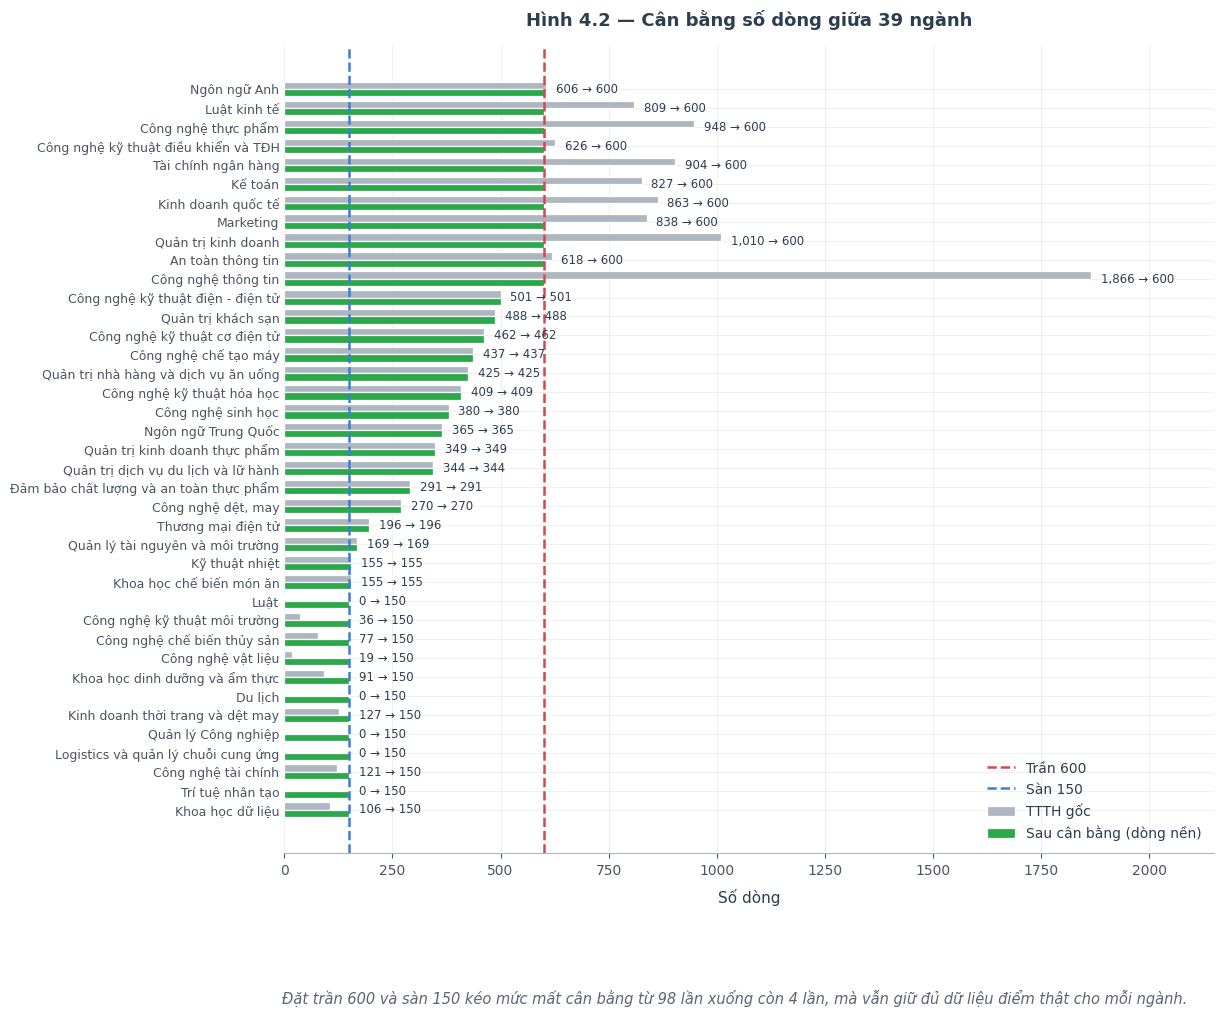

In [6]:
# ═══════════ HÌNH 4.2 — Cân bằng lớp ═══════════
fig, ax = plt.subplots(figsize=(12, 10.5))

thu_tu = sorted(NGANH_TO_KHOI, key=lambda m: vc_nen[m])
y = np.arange(39); h = 0.38
goc = [vc_ttth.get(m, 0) for m in thu_tu]
sau = [vc_nen[m] for m in thu_tu]

ax.barh(y + h/2, goc, h, label="TTTH gốc", color=C_XAM, edgecolor="white", linewidth=0.9)
ax.barh(y - h/2, sau, h, label="Sau cân bằng (dòng nền)", color=C_GA,
        edgecolor="white", linewidth=0.9)
for i, (g, s) in enumerate(zip(goc, sau)):
    ax.text(max(g, s) + 22, i, f"{g:,} → {s:,}", va="center", fontsize=8.5, color=C_DAM)

ax.axvline(CAP_MAX, color=C_THAT, ls="--", lw=1.8, label=f"Trần {CAP_MAX}")
ax.axvline(CAP_MIN, color=C_XANH, ls="--", lw=1.8, label=f"Sàn {CAP_MIN}")
ax.set_yticks(y); ax.set_yticklabels([MA_TO_TEN[m] for m in thu_tu], fontsize=9)
ax.set_xlabel("Số dòng"); ax.set_xlim(0, 2150)
ax.set_title("Hình 4.2 — Cân bằng số dòng giữa 39 ngành")
ax.legend(loc="lower right", fontsize=10); ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

luu(fig, OUTPUT_DIR, "hinh_4_2_can_bang_lop.png",
    f"Đặt trần {CAP_MAX} và sàn {CAP_MIN} kéo mức mất cân bằng từ {vc_ttth.max()/vc_ttth.min():.0f} lần "
    f"xuống còn {vc_nen.max()/vc_nen.min():.0f} lần, mà vẫn giữ đủ dữ liệu điểm thật cho mỗi ngành.")
plt.show()

## 4. Sinh dữ liệu — bộ "sản xuất"

In [7]:
def sinh_cot_thieu(df_nen, phan_phoi, seed):
    # Sinh 10 câu Likert (bằng GA) + giới tính + mục tiêu cho từng ngành
    r = np.random.default_rng(seed)
    likert = np.zeros((len(df_nen), 10), dtype=int)
    gioi = np.empty(len(df_nen), dtype=object)
    mt   = np.empty(len(df_nen), dtype=object)
    for ma, idx in df_nen.groupby("ma_nganh").groups.items():
        idx = np.asarray(idx)
        d = phan_phoi[str(ma)]
        likert[idx] = sinh_likert_ga(len(idx), d["likert_mean"], d["likert_cov"], r)
        gioi[idx] = np.where(r.random(len(idx)) < d["gioi_tinh_ty_le_nam"], "Nam", "Nu")
        keys = list(d["muc_tieu_phan_phoi"])
        p = np.array(list(d["muc_tieu_phan_phoi"].values()), float)
        mt[idx] = r.choice(keys, size=len(idx), p=p / p.sum())
    return likert, gioi, mt


t0 = time.time()
likert_sx, gioi_sx, mt_sx = sinh_cot_thieu(df_nen, PP, SEED)

df_synth = df_nen.copy()
df_synth[LIKERT_COLS]      = likert_sx
df_synth["gioi_tinh"]      = gioi_sx
df_synth["muc_tieu_nhan"]  = mt_sx
df_synth["muc_tieu_ma"]    = pd.Series(mt_sx).map(MUC_TIEU_MA).values
df_synth["nganh_hoc"]      = df_synth["ma_nganh"].map(MA_TO_TEN)
df_synth["ten_khoi_nganh"] = df_synth["ma_khoi_nganh"].map(TEN_KHOI)
df_synth["nguon_du_lieu"]  = "synthetic_GA"

# --- Kiểm tra bắt buộc --------------------------------------------------------
assert df_synth["ma_nganh"].nunique() == 39, "Phải sinh đủ 39 ngành"
assert df_synth[LIKERT_COLS].stack().between(1, 5).all(), "Likert phải trong [1,5]"
assert (df_synth[DIEM_COLS].notna().sum(axis=1) == 3).all(), "Phải giữ đúng 3 điểm thật"
tl_thang = df_synth[LIKERT_COLS].nunique(axis=1).eq(1).mean()
assert tl_thang < 0.02, f"Sinh ra quá nhiều phiếu 'điền đại': {tl_thang:.1%}"

df_synth.to_csv(OUTPUT_DIR / "synthetic_GA_data.csv", index=False, encoding="utf-8-sig")
print(f"✅ synthetic_GA_data.csv — {len(df_synth):,} dòng × {df_synth.shape[1]} cột, đủ 39 ngành")
print(f"   Điểm thi + tổ hợp            : THẬT (giữ nguyên từ hồ sơ trúng tuyển)")
print(f"   Likert + giới tính + mục tiêu: GA sinh")
print(f"   Thời gian sinh               : {time.time()-t0:.1f} giây")

✅ synthetic_GA_data.csv — 13,796 dòng × 30 cột, đủ 39 ngành
   Điểm thi + tổ hợp            : THẬT (giữ nguyên từ hồ sơ trúng tuyển)
   Likert + giới tính + mục tiêu: GA sinh
   Thời gian sinh               : 4.0 giây


   💾 Đã lưu hình: hinh_4_3_tong_hop_vs_that.png


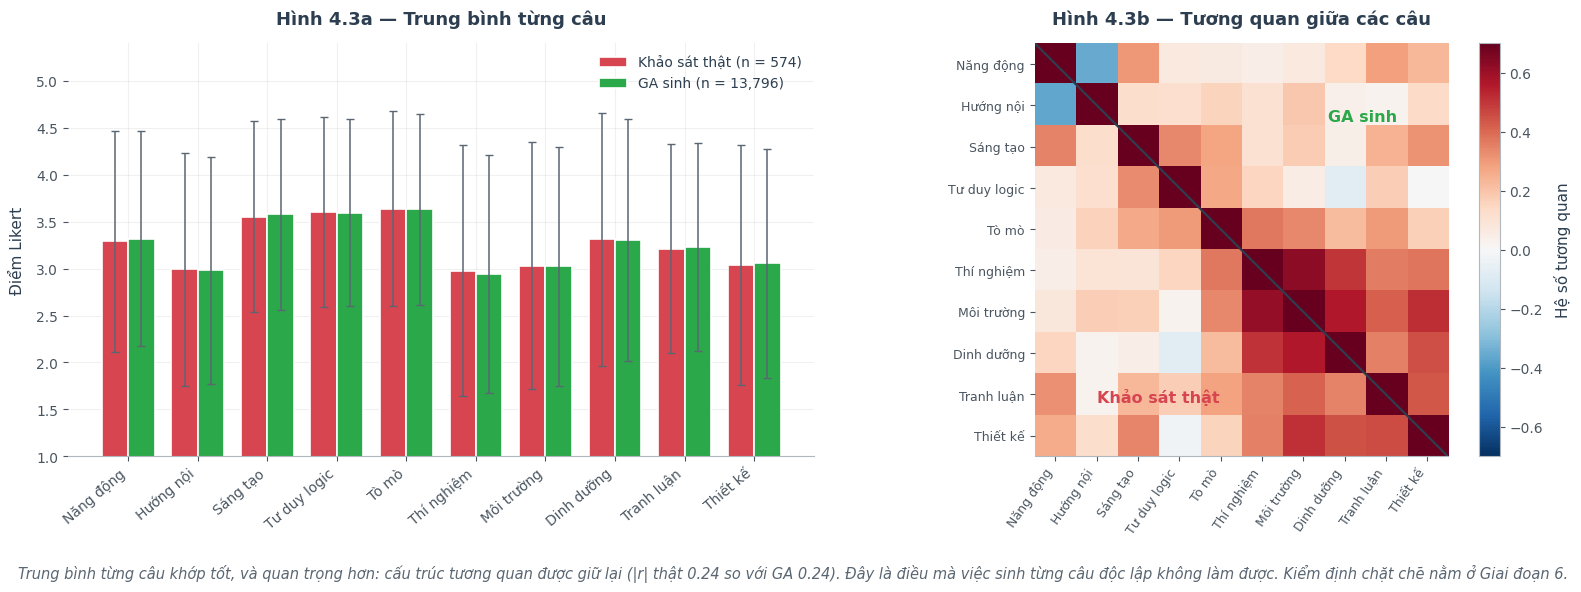

In [8]:
# ═══════════ HÌNH 4.3 — Dữ liệu tổng hợp so với dữ liệu thật ═══════════
df_that = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1.2, 1]})

# (a) Trung bình ± độ lệch chuẩn từng câu
ax = axes[0]
x = np.arange(10); w = 0.38
tb_t, sd_t = df_that[LIKERT_COLS].mean().values, df_that[LIKERT_COLS].std().values
tb_g, sd_g = df_synth[LIKERT_COLS].mean().values, df_synth[LIKERT_COLS].std().values
ax.bar(x - w/2, tb_t, w, yerr=sd_t, label=f"Khảo sát thật (n = {len(df_that)})",
       color=C_THAT, edgecolor="white", linewidth=1.2,
       error_kw={"ecolor": "#5A6672", "capsize": 3, "lw": 1.1})
ax.bar(x + w/2, tb_g, w, yerr=sd_g, label=f"GA sinh (n = {len(df_synth):,})",
       color=C_GA, edgecolor="white", linewidth=1.2,
       error_kw={"ecolor": "#5A6672", "capsize": 3, "lw": 1.1})
ax.set_xticks(x); ax.set_xticklabels(NHAN, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Điểm Likert"); ax.set_ylim(1, 5.4)
ax.set_title("Hình 4.3a — Trung bình từng câu")
ax.legend(loc="upper right"); ax.set_axisbelow(True)

# (b) Ma trận tương quan: thật (dưới) vs GA (trên)
ax = axes[1]
corr_t = np.corrcoef(df_that[LIKERT_COLS].to_numpy(float), rowvar=False)
corr_g = np.corrcoef(df_synth[LIKERT_COLS].to_numpy(float), rowvar=False)
M = np.tril(corr_t, -1) + np.triu(corr_g, 1) + np.eye(10)
im = ax.imshow(M, cmap="RdBu_r", vmin=-0.7, vmax=0.7)
ax.plot([-0.5, 9.5], [-0.5, 9.5], color=C_DAM, lw=1.6)
ax.text(6.6, 1.4, "GA sinh", fontsize=11.5, fontweight="bold", color=C_GA)
ax.text(1.0, 8.2, "Khảo sát thật", fontsize=11.5, fontweight="bold", color=C_THAT)
ax.set_xticks(range(10)); ax.set_xticklabels(NHAN, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(10)); ax.set_yticklabels(NHAN, fontsize=9)
ax.set_title("Hình 4.3b — Tương quan giữa các câu")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, label="Hệ số tương quan")

plt.tight_layout()
iu = np.triu_indices(10, 1)
luu(fig, OUTPUT_DIR, "hinh_4_3_tong_hop_vs_that.png",
    f"Trung bình từng câu khớp tốt, và quan trọng hơn: cấu trúc tương quan được giữ lại "
    f"(|r| thật {np.abs(corr_t[iu]).mean():.2f} so với GA {np.abs(corr_g[iu]).mean():.2f}). "
    "Đây là điều mà việc sinh từng câu độc lập không làm được. "
    "Kiểm định chặt chẽ nằm ở Giai đoạn 6.")
plt.show()

   💾 Đã lưu hình: hinh_4_4_giu_nguyen_diem_va_ty_le.png


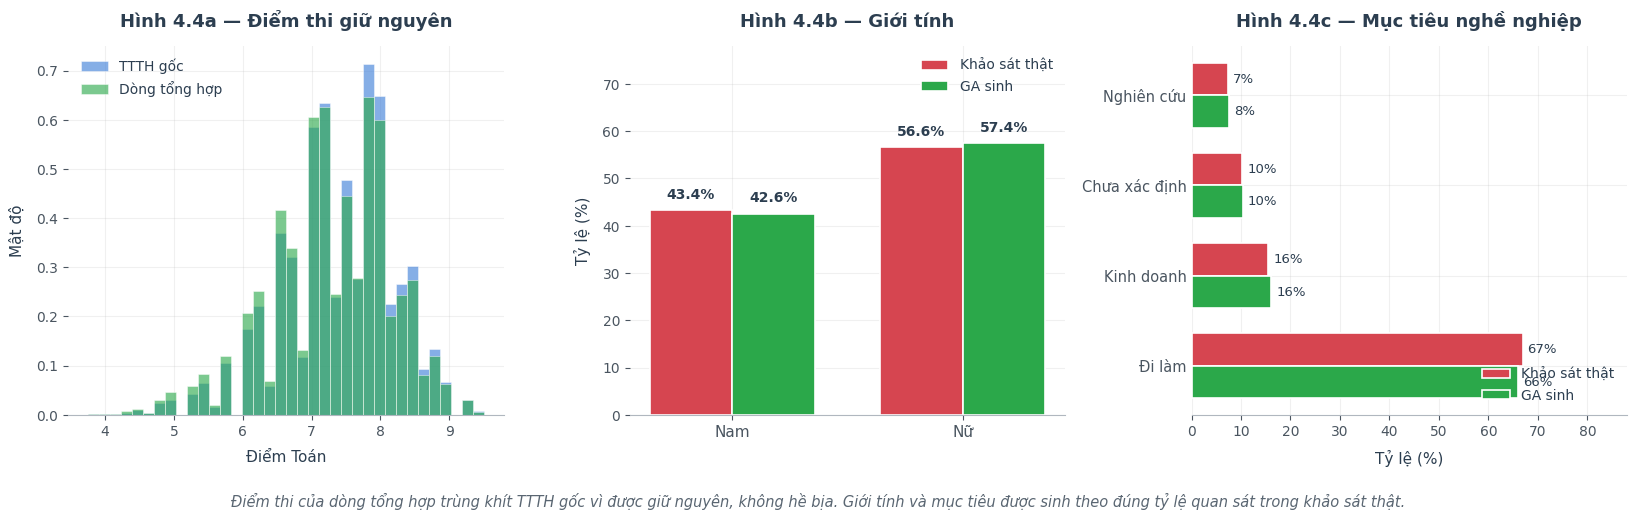

In [9]:
# ═══════════ HÌNH 4.4 — Điểm thi được giữ nguyên ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))

# (a) Phân bố điểm Toán: TTTH gốc vs dòng tổng hợp
ax = axes[0]
ax.hist(df_ttth["diem_Toan"].dropna(), bins=36, alpha=0.62, label="TTTH gốc",
        color=C_XANH, density=True, edgecolor="white", linewidth=0.5)
ax.hist(df_synth["diem_Toan"].dropna(), bins=36, alpha=0.62, label="Dòng tổng hợp",
        color=C_GA, density=True, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Điểm Toán"); ax.set_ylabel("Mật độ")
ax.set_title("Hình 4.4a — Điểm thi giữ nguyên")
ax.legend(); ax.set_axisbelow(True)

# (b) Giới tính
ax = axes[1]
gt_t = df_that["gioi_tinh"].replace({"Nữ": "Nu"}).value_counts(normalize=True)
gt_g = df_synth["gioi_tinh"].value_counts(normalize=True)
x = np.arange(2); w = 0.36
ax.bar(x - w/2, [gt_t.get("Nam", 0)*100, gt_t.get("Nu", 0)*100], w,
       label="Khảo sát thật", color=C_THAT, edgecolor="white", linewidth=1.2)
ax.bar(x + w/2, [gt_g.get("Nam", 0)*100, gt_g.get("Nu", 0)*100], w,
       label="GA sinh", color=C_GA, edgecolor="white", linewidth=1.2)
nhan_doc(ax, "{:.1f}%", lui=0.03, fs=10)
ax.set_xticks(x); ax.set_xticklabels(["Nam", "Nữ"], fontsize=11)
ax.set_ylabel("Tỷ lệ (%)"); ax.set_ylim(0, 78)
ax.set_title("Hình 4.4b — Giới tính")
ax.legend(); ax.set_axisbelow(True)

# (c) Mục tiêu nghề nghiệp
ax = axes[2]
keys = ["Đi làm", "Kinh doanh", "Chưa xác định", "Nghiên cứu"]
mt_t = df_that["muc_tieu_nhan"].value_counts(normalize=True).reindex(keys).fillna(0) * 100
mt_g = df_synth["muc_tieu_nhan"].value_counts(normalize=True).reindex(keys).fillna(0) * 100
y = np.arange(4); h = 0.36
ax.barh(y + h/2, mt_t.values, h, label="Khảo sát thật", color=C_THAT,
        edgecolor="white", linewidth=1.2)
ax.barh(y - h/2, mt_g.values, h, label="GA sinh", color=C_GA, edgecolor="white", linewidth=1.2)
for i in range(4):
    ax.text(mt_t.values[i] + 1, i + h/2, f"{mt_t.values[i]:.0f}%", va="center", fontsize=9.5)
    ax.text(mt_g.values[i] + 1, i - h/2, f"{mt_g.values[i]:.0f}%", va="center", fontsize=9.5)
ax.set_yticks(y); ax.set_yticklabels(keys, fontsize=10.5)
ax.set_xlabel("Tỷ lệ (%)"); ax.set_xlim(0, 88)
ax.set_title("Hình 4.4c — Mục tiêu nghề nghiệp")
ax.legend(loc="lower right"); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_4_4_giu_nguyen_diem_va_ty_le.png",
    "Điểm thi của dòng tổng hợp trùng khít TTTH gốc vì được giữ nguyên, không hề bịa. "
    "Giới tính và mục tiêu được sinh theo đúng tỷ lệ quan sát trong khảo sát thật.")
plt.show()

## 5. Sinh dữ liệu riêng cho từng fold

Bộ "sản xuất" ở trên học từ **cả 574 phiếu train**. Nếu dùng nó để đo Cross-Validation thì dòng tổng
hợp trong TRAIN của một fold đã "biết" đôi chút về dòng thật trong VAL của fold đó → chỉ số bị lạc quan.

Ở đây ta sinh thêm một bộ cho mỗi fold, **chỉ dùng phân phối học từ phần train của fold đó**.
Bảng dòng nền (điểm thi thật) giữ nguyên giữa các fold — chỉ các cột do GA sinh thay đổi — nên chỉ
cần lưu phần thay đổi vào một file `.npz` nhỏ gọn.

In [10]:
t0 = time.time()
goi = {}
for fid, pp_f in PP_FOLD.items():
    lk, gt, mt = sinh_cot_thieu(df_nen, pp_f, SEED + 1000 + int(fid))
    goi[f"likert_{fid}"]  = lk.astype(np.int8)
    goi[f"gioi_{fid}"]    = (gt == "Nam").astype(np.int8)
    goi[f"muctieu_{fid}"] = pd.Series(mt).map(MUC_TIEU_MA).values.astype(np.int8)

np.savez_compressed(OUTPUT_DIR / "synthetic_per_fold.npz", **goi,
                    n_folds=np.array([len(PP_FOLD)]))
kb = (OUTPUT_DIR / "synthetic_per_fold.npz").stat().st_size / 1024

print(f"✅ synthetic_per_fold.npz — {len(PP_FOLD)} fold × {len(df_nen):,} dòng  ({kb:,.0f} KB)")
print(f"   Thời gian sinh: {time.time()-t0:.0f} giây")

print("\n" + "═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 4")
print("═" * 68)
print(f"  Hồ sơ TTTH đầu vào            {len(df_ttth):>10,}")
print(f"  Dòng tổng hợp sinh ra         {len(df_synth):>10,}")
print(f"  Số ngành                      {df_synth['ma_nganh'].nunique():>10} / 39")
print(f"  Mất cân bằng                  {vc_ttth.max()/vc_ttth.min():>9.0f}× → {vc_nen.max()/vc_nen.min():.0f}×")
print(f"  GA cải thiện so với lấy mẫu   {1 - L_TIEN_HOA/L_1LAN:>9.1%}")
print(f"  Bộ dữ liệu theo fold          {len(PP_FOLD):>10}")
print("═" * 68)
print(f"\n  Hình đã lưu tại: {OUTPUT_DIR}/")

✅ synthetic_per_fold.npz — 15 fold × 13,796 dòng  (742 KB)
   Thời gian sinh: 49 giây

════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 4
════════════════════════════════════════════════════════════════════
  Hồ sơ TTTH đầu vào                15,888
  Dòng tổng hợp sinh ra             13,796
  Số ngành                              39 / 39
  Mất cân bằng                         98× → 4×
  GA cải thiện so với lấy mẫu       55.2%
  Bộ dữ liệu theo fold                  15
════════════════════════════════════════════════════════════════════

  Hình đã lưu tại: ../data/processed/04_synthetic/
